In [1]:
pip install pandas plotly nbformat nbclient ipywidgets matplotlib "urllib3<2"

You should consider upgrading via the '/Users/stripura/Desktop/ocp-workload-analysis-/venv/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURATION SECTION ---
# Tune these multipliers to change how "Large" or "Small" is calculated
COMPLEXITY_CONFIG = {
    "weights": {
        "cpu_high": 3,      # Points if CPU > threshold_cpu_high
        "cpu_med": 1,       # Points if CPU > threshold_cpu_med
        "mem_high": 3,      # Points if Mem > threshold_mem_high
        "mem_med": 1,       # Points if Mem > threshold_mem_med
        "pvc_presence": 4,  # Points if any PVC is attached
        "net_complexity": 2 # Points if multiple ports are used
    },
    "thresholds": {
        "cpu_high": 2.0,    # Cores
        "cpu_med": 0.5,     # Cores
        "mem_high": 4096,   # MiB
        "mem_med": 1024,    # MiB
        "net_ports": 2,     # Number of ports
        "tier_large": 7,    # Total points to be 'Large'
        "tier_medium": 3    # Total points to be 'Medium'
    }
}

# --- DYNAMIC GRADING FUNCTION ---

def assign_tier_from_config(row, cfg):
    score = 0
    w = cfg["weights"]
    t = cfg["thresholds"]
    
    # 1. CPU Scoring
    cpu = row.get('cpu_val', 0)
    if cpu >= t["cpu_high"]: score += w["cpu_high"]
    elif cpu >= t["cpu_med"]: score += w["cpu_med"]
        
    # 2. Memory Scoring
    mem = row.get('mem_val', 0)
    if mem >= t["mem_high"]: score += w["mem_high"]
    elif mem >= t["mem_med"]: score += w["mem_med"]
    
    # 3. Storage Scoring (PVC)
    if row.get('PVC_Count', 0) > 0:
        score += w["pvc_presence"]
        
    # 4. Network Scoring
    if row.get('Network_Interfaces_Ports', 1) > t["net_ports"]:
        score += w["net_complexity"]

    # 5. Tier Assignment
    if score >= t["tier_large"]: return 'Large'
    if score >= t["tier_medium"]: return 'Medium'
    return 'Small'

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURATION SECTION ---
# Tune these multipliers to change how "Large" or "Small" is calculated
COMPLEXITY_CONFIG = {
    "weights": {
        "cpu_high": 3,      # Points if CPU > threshold_cpu_high
        "cpu_med": 1,       # Points if CPU > threshold_cpu_med
        "mem_high": 3,      # Points if Mem > threshold_mem_high
        "mem_med": 1,       # Points if Mem > threshold_mem_med
        "pvc_presence": 4,  # Points if any PVC is attached
        "net_complexity": 2 # Points if multiple ports are used
    },
    "thresholds": {
        "cpu_high": 2.0,    # Cores
        "cpu_med": 0.5,     # Cores
        "mem_high": 4096,   # MiB
        "mem_med": 1024,    # MiB
        "net_ports": 2,     # Number of ports
        "tier_large": 7,    # Total points to be 'Large'
        "tier_medium": 3    # Total points to be 'Medium'
    }
}

# --- DYNAMIC GRADING FUNCTION ---

def assign_tier_from_config(row, cfg):
    score = 0
    w = cfg["weights"]
    t = cfg["thresholds"]
    
    # 1. CPU Scoring
    cpu = row.get('cpu_val', 0)
    if cpu >= t["cpu_high"]: score += w["cpu_high"]
    elif cpu >= t["cpu_med"]: score += w["cpu_med"]
        
    # 2. Memory Scoring
    mem = row.get('mem_val', 0)
    if mem >= t["mem_high"]: score += w["mem_high"]
    elif mem >= t["mem_med"]: score += w["mem_med"]
    
    # 3. Storage Scoring (PVC)
    if row.get('PVC_Count', 0) > 0:
        score += w["pvc_presence"]
        
    # 4. Network Scoring
    if row.get('Network_Interfaces_Ports', 1) > t["net_ports"]:
        score += w["net_complexity"]

    # 5. Tier Assignment
    if score >= t["tier_large"]: return 'Large'
    if score >= t["tier_medium"]: return 'Medium'
    return 'Small'

import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURATION SECTION ---
# Tune these multipliers to change how "Large" or "Small" is calculated
COMPLEXITY_CONFIG = {
    "weights": {
        "cpu_high": 3,      # Points if CPU > threshold_cpu_high
        "cpu_med": 1,       # Points if CPU > threshold_cpu_med
        "mem_high": 3,      # Points if Mem > threshold_mem_high
        "mem_med": 1,       # Points if Mem > threshold_mem_med
        "pvc_presence": 4,  # Points if any PVC is attached
        "net_complexity": 2 # Points if multiple ports are used
    },
    "thresholds": {
        "cpu_high": 2.0,    # Cores
        "cpu_med": 0.5,     # Cores
        "mem_high": 4096,   # MiB
        "mem_med": 1024,    # MiB
        "net_ports": 2,     # Number of ports
        "tier_large": 7,    # Total points to be 'Large'
        "tier_medium": 3    # Total points to be 'Medium'
    }
}

# --- DYNAMIC GRADING FUNCTION ---

def assign_tier_from_config(row, cfg):
    score = 0
    w = cfg["weights"]
    t = cfg["thresholds"]
    
    # 1. CPU Scoring
    cpu = row.get('cpu_val', 0)
    if cpu >= t["cpu_high"]: score += w["cpu_high"]
    elif cpu >= t["cpu_med"]: score += w["cpu_med"]
        
    # 2. Memory Scoring
    mem = row.get('mem_val', 0)
    if mem >= t["mem_high"]: score += w["mem_high"]
    elif mem >= t["mem_med"]: score += w["mem_med"]
    
    # 3. Storage Scoring (PVC)
    if row.get('PVC_Count', 0) > 0:
        score += w["pvc_presence"]
        
    # 4. Network Scoring
    if row.get('Network_Interfaces_Ports', 1) > t["net_ports"]:
        score += w["net_complexity"]

    # 5. Tier Assignment
    if score >= t["tier_large"]: return 'Large'
    if score >= t["tier_medium"]: return 'Medium'
    return 'Small'

def create_config_driven_dashboard(df, cfg):
    # Apply logic using the config
    df['Size_Tier'] = df.apply(lambda x: assign_tier_from_config(x, cfg), axis=1)
    
    # Prepare Plotting Data
    tier_order = ['Small', 'Medium', 'Large']
    counts = df['Size_Tier'].value_counts().reindex(tier_order, fill_value=0)
    colors = ['#4CAF50', '#FF9800', '#F44336']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Pie Chart
    counts.plot(kind='pie', ax=ax1, autopct='%1.1f%%', colors=colors, startangle=140, 
                wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax1.set_title("Workload Complexity Share", fontweight='bold')
    
    # Bar Chart
    counts.plot(kind='bar', ax=ax2, color=colors, edgecolor='black', alpha=0.8)
    ax2.set_title("Workload Counts", fontweight='bold')
    
    for i, v in enumerate(counts):
        ax2.text(i, v + (max(counts)*0.01), str(v), ha='center', fontweight='bold')

    plt.suptitle("Config-Driven K8s Analysis", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

# --- EXECUTION ---
# create_config_driven_dashboard(df, COMPLEXITY_CONFIG)

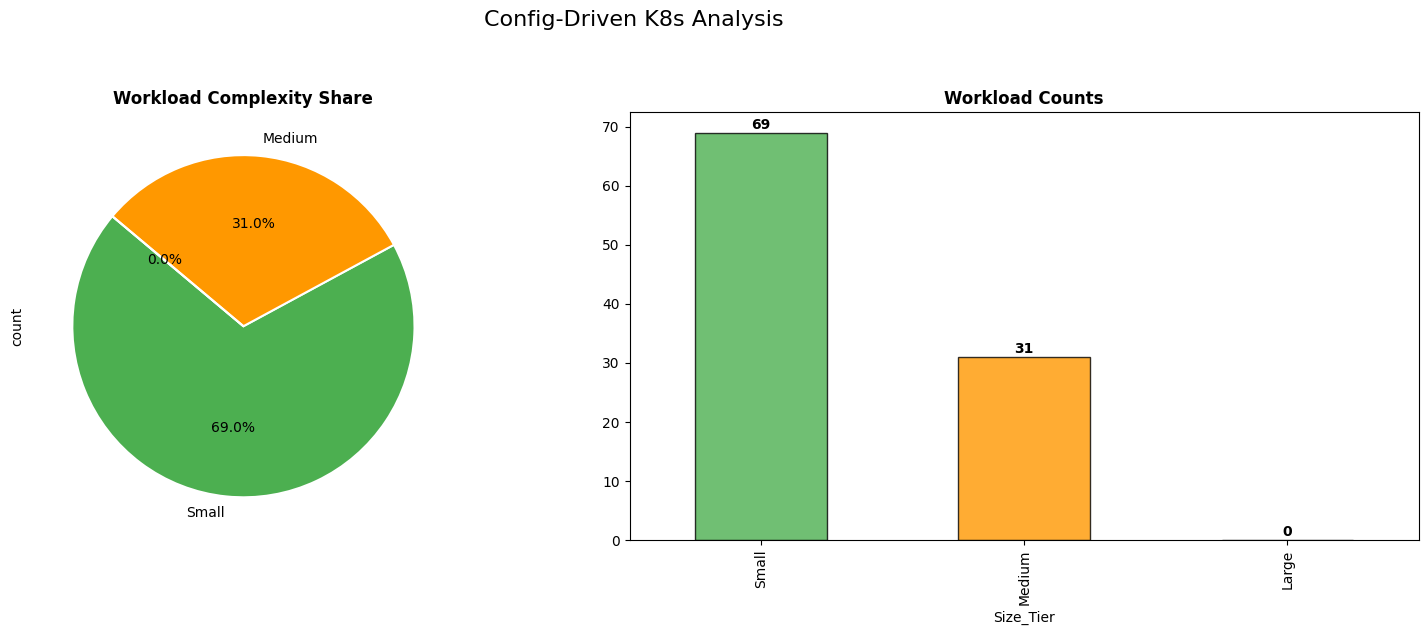

In [5]:
# Load your generated CSV
df = pd.read_csv('sample_data/k8s_sample_100_rows.csv')


create_config_driven_dashboard(df, COMPLEXITY_CONFIG)

# Convert resource strings to numbers for math
#df['cpu_val'] = df['CPU_Limit'].apply(parse_cpu)
#df['mem_val'] = df['Mem_Limit'].apply(parse_mem)

# Apply Categorization
#df['Size_Tier'] = df.apply(assign_tier, axis=1)

# Summary Table
#summary = df.groupby('Size_Tier').size().reset_index(name='Count')
#print("--- Workload Distribution Summary ---")
#print(summary)

In [ ]:
# Export the final graded list to CSV
df.to_csv('k8s_final_graded_inventory.csv', index=False)
print("Success! Final graded inventory saved to 'k8s_final_graded_inventory.csv'")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. THE NAMESPACE GRADING FUNCTION
def assign_ns_tier(row):
    score = 0
    
    # Workload Count (Deployments + StatefulSets)
    workloads = row.get('Deployments', 0) + row.get('StatefulSets', 0)
    score += (workloads * 1)
    
    # Pod Density
    pods = row.get('Pods', 0)
    score += (pods * 0.5)
    
    # Storage Complexity (PVCs)
    pvcs = row.get('PVCs', 0)
    score += (pvcs * 3)
    
    # Networking & Security Overhead
    net_ops = row.get('NetworkPolicies', 0) + row.get('Ingress', 0)
    score += (net_ops * 2)

    # Final Namespace Grading
    # Adjust these thresholds based on your cluster size
    if score >= 50:
        return 'Large'
    elif score >= 15:
        return 'Medium'
    else:
        return 'Small'

# 2. THE NAMESPACE DASHBOARD HELPER
def create_ns_complexity_dashboard(df):
    """
    Standardized helper to generate Pie and Bar charts for Namespaces.
    """
    # Apply the Tiering Logic
    df['NS_Complexity_Tier'] = df.apply(assign_ns_tier, axis=1)
    
    # Prepare Data
    tier_order = ['Small', 'Medium', 'Large']
    counts = df['NS_Complexity_Tier'].value_counts().reindex(tier_order, fill_value=0)
    colors = ['#8BC34A', '#2196F3', '#673AB7'] # Different color palette (Green, Blue, Purple)
    
    # Setup Figure
    fig, (ax_pie, ax_bar) = plt.subplots(1, 2, figsize=(16, 7))
    
    # --- PIE CHART ---
    counts.plot(kind='pie', ax=ax_pie, autopct='%1.1f%%', colors=colors, startangle=140,
                wedgeprops={'edgecolor': 'white', 'linewidth': 2}, textprops={'fontweight': 'bold'})
    ax_pie.set_title('Namespace Complexity Share', fontsize=14, pad=15)
    ax_pie.set_ylabel('')

    # --- BAR CHART ---
    counts.plot(kind='bar', ax=ax_bar, color=colors, edgecolor='black', alpha=0.8)
    ax_bar.set_title('Namespace Counts by Tier', fontsize=14, pad=15)
    ax_bar.set_xlabel('Namespace Complexity', fontsize=12)
    ax_bar.set_ylabel('Number of Namespaces', fontsize=12)
    ax_bar.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add labels
    for i, v in enumerate(counts):
        ax_bar.text(i, v + (max(counts) * 0.02), str(v), ha='center', fontweight='bold')

    plt.suptitle('Kubernetes Namespace Complexity Analysis', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()



In [ ]:
# --- HOW TO RUN ---
df_ns = pd.read_csv('sample_data/k8s_ns_100_sample.csv')
create_ns_complexity_dashboard(df_ns)